# 0.1 - Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.causal_discovery import HillClimbSearch
from pgmpy.inference import VariableElimination

import networkx as nx

c:\Users\nicol\miniforge3\envs\ai_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nicol\miniforge3\envs\ai_project\lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (



# 0.2 - Load the data

In [2]:
DATA_PATH = 'data\diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATA_PATH)


print(f'Shape : {df_raw.shape[0]} obs, {df_raw.shape[1]} variables')
print(f'Valeurs manquantes : {df_raw.isnull().sum().sum()}')
print(list(df_raw.columns))

Shape : 70692 obs, 22 variables
Valeurs manquantes : 0
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [14]:
#set the seed for the all pipeline
SEED = 44

# 1 - Preprocessing

## 1.1 - Discretize

To simplify the features we'll discretize 3 of them : BMI, MentHlth and PhysHlth
*   BMI : convert the feature into 5 subclasses based on the World Health Organization.
    *   $0 < \text{Underweight} \le 18.5$
    *   $18.5 < \text{Normal weight} \le 25$
    *   $25 < \text{Overweight} \le 30$
    *   $30 < \text{Obesity I} \le 35$
    *   $35 < \text{Obesity II}$

*   MentHlth and PhysHlth : convert these features into 4 intervalles. 
    *   0 = 0-7 day  |  1 = 8-14 days  |  2 = 15-21 days  |  3 = 22-30 days

In [15]:
df = df_raw.copy().astype(int)

# divide the BMI values into 5 sub classes from the OMS
def disc_bmi(x):
    if x <= 18.5:    
        return 0
    elif x <= 25:  
        return 1
    elif x <= 30: 
        return 2
    elif x <= 35:         
        return 3
    else:
        return 4
    
df['BMI'] = df['BMI'].apply(disc_bmi)

# divide the MentHlth and PhysHlthinto features into 4 sub classes. 0:'0-7 day', 1:'8-14 days', 2:'15-21 days', 3:'22-30 days'
def disc_days(x):
    if x < 8:    
        return 0
    elif x < 15:  
        return 1
    elif x < 22: 
        return 2
    else:         
        return 3

df['MentHlth'] = df['MentHlth'].apply(disc_days)
df['PhysHlth'] = df['PhysHlth'].apply(disc_days)

display(df[['BMI', 'MentHlth', 'PhysHlth']].describe())

,BMI,MentHlth,PhysHlth
count,70692.000000,70692.000000,70692.000000
mean,2.273567,0.335625,0.529027
std,1.057275,0.855695,1.053917
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000
max,4.000000,3.000000,3.000000


## 1.2 - Split Train / Test

To assess the quality of the bayesian network we'll split the dataset into a train and test set. The network will be build on the train set and the predictions will be made on the test set. The test set will be used only at the end for the evaluation in order to avoid any data leakage. Data leakage can induces an overfitting of the predictive model.
the train set will represent 80% and the test set will represent 20% of the full dataset. These two sets will be randomly generated thanks to the train_test_split function from the sklearn package ([link](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [16]:
TARGET   = 'Diabetes_binary'
FEATURES = [c for c in df.columns if c != TARGET]

X_train, X_test, y_train, y_test = train_test_split(df[FEATURES], df[TARGET], test_size=0.2, random_state=SEED, stratify=df[TARGET])

#merge the features dataframe with target feature dataframe
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)

print(f'Train : {len(df_train)} obs.  |  Test : {len(df_test)} obs.')

Train : 56553 obs.  |  Test : 14139 obs.


# 2 - Build the bayesian network

To build a Bayesian network, we first need to build the dependency graph. It can be built manually with some prior knowledge of the features and their dependencies. Here, we want to determine if a patient is diabetic or not, considering different health information, social characteristics, and other factors. To avoid any bias and compensate for a lack of specialized medical knowledge, we'll employed the HillClimbSearch algorithm for automated structure learning.
The graph will be visualized thanks to [networkx](https://networkx.org/en/) and [matplotlib](https://matplotlib.org/) packages .\
Subsequently, the bayesian network model is built by computing the CPTs. 

## 2.1 - Hill Climbing

This function implements the HillClimbSearch algorithm for causal discovery. Given a tabular dataset, the algorithm estimates the causal structure among the variables in the data as a Directed Acyclic Graph (DAG). The algorithm works by iteratively making local modifications to the graph structure (adding, removing, or reversing edges) and keeping changes that improve the score until a local maximum is reached.

The algorithm is a greedy local search method that: 1. Starts from an initial graph (empty by default or based on provided expert knowledge). 2. Evaluates all possible single-edge modifications (add, delete, reverse). 3. Applies the modification with the highest score improvement. 4. Repeats until no improvement can be made.
[source](https://pgmpy.org/api/generated/structure_learning/pgmpy.causal_discovery.HillClimbSearch.html)

In our case, no prior knowledge on the dataset is assumed. Therefore, likelihood maximization based metrics could be used to indentify the optimal graph like the maximum log-likelihood $\hat{l}(m)$ or AIC and BIC scores which are both penalty functions of the maximum log-likelihood. Since the maximum log-likelihood is not adequate for a complex model like ours with 22 features, we'll use the penalty function BIC ( $\hat{l}(m) - \frac{1}{2}d_m \log{n}$ ) which is asymptotically consistent when the sample size is large. The AIC penalty function ( $\hat{l}(m) - d_m$ ) just add a penalty without considering the sample size.

[Cowell, Robert G. (1999). Structural Learning. In: Probabilistic Networks and Expert Systems. Information Science and Statistics. Springer, New York, NY.](https://doi-org.ezproxy.ulb.ac.be/10.1007/0-387-22630-3_11)

In [17]:
hc = HillClimbSearch(scoring_method = 'bic-d',max_iter = 500)
hc.fit(df_train)
hc_dag = hc.causal_graph_

 12%|█▏        | 58/500 [00:06<00:52,  8.37it/s]


In [18]:
#Bayesian networks cannot include loops
#remove any loops created by mystake by the hc algorithm
if len(list(nx.simple_cycles(hc_dag))) > 0 :
    cycles = list(nx.simple_cycles(hc_dag))
    while len(cycles) > 0:
        cycle = cycles[0]
        edge = (cycle[0], cycle[1])
        hc_dag.remove_edge(*edge)
        cycles = list(nx.simple_cycles(hc_dag))

print(f'\n Network : {len(hc_dag.edges())} arrows')
for e in sorted(hc_dag.edges()):
    print(f'  {e[0]} → {e[1]}', end = '')

print(f'\n Network : {len(hc_dag.nodes())} nodes')
for node in hc_dag.nodes():
    print(f'{node}')


 Network : 57 arrows
  Age → AnyHealthcare  Age → HeartDiseaseorAttack  Age → HighChol  AnyHealthcare → CholCheck  BMI → HighBP  Diabetes_binary → Age  Diabetes_binary → BMI  Diabetes_binary → CholCheck  Diabetes_binary → HighBP  Diabetes_binary → HighChol  Diabetes_binary → HvyAlcoholConsump  DiffWalk → Age  DiffWalk → BMI  DiffWalk → Diabetes_binary  DiffWalk → GenHlth  DiffWalk → HvyAlcoholConsump  DiffWalk → PhysActivity  DiffWalk → PhysHlth  DiffWalk → Stroke  Education → Fruits  Education → Income  Education → Smoker  Education → Veggies  Fruits → PhysActivity  Fruits → Sex  GenHlth → BMI  GenHlth → Diabetes_binary  GenHlth → HeartDiseaseorAttack  GenHlth → HighBP  GenHlth → MentHlth  GenHlth → PhysActivity  GenHlth → PhysHlth  GenHlth → Stroke  HeartDiseaseorAttack → HighChol  HeartDiseaseorAttack → Sex  HeartDiseaseorAttack → Stroke  HighBP → Age  HighBP → CholCheck  HighBP → HighChol  HighBP → Stroke  Income → DiffWalk  Income → GenHlth  Income → NoDocbcCost  Income → Sex  Me

Diabetes_binary


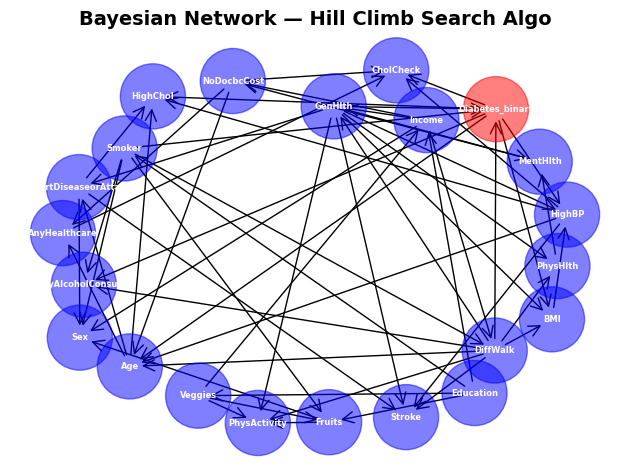

In [19]:
def plot_bn(dag, title, target=TARGET, n_seed=42):
    """ 
        Display the Directed Acyclic Graph (DAG)
    Param:
        > dag   : the Directed Acyclic Graph
        > title : string representing the title to show on the plot
        > target: string representing the target feature
        > n_seed: int for the random seed
    Return: None
    """
    
    print(target)
    G = nx.DiGraph(dag.edges())
    colors = ['red' if n==target else 'blue' for n in dag.nodes()]

    pos = nx.spring_layout(dag, seed=n_seed, k=3.0)
    nx.draw_networkx_nodes(dag, pos, node_color=colors, node_size=2200, alpha=0.5)
    nx.draw_networkx_labels(dag, pos, font_size=6, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(dag, pos, edge_color='black', arrows=True, arrowsize=20, arrowstyle='->', width=1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_bn(hc_dag, title = 'Bayesian Network — Hill Climb Search Algo', n_seed = SEED)

## 2.2 - CPTs

Given that we only have discrete features in the dataset, the bayesian network will be created thanks to the [DiscreteBayesianNetwork](https://pgmpy.org/api/generated/models/pgmpy.models.DiscreteBayesianNetwork.html#pgmpy.models.DiscreteBayesianNetwork) from the pgmpy package. the nodes and the edges of the previous built DAG will be add to the network. We'll use the fit attribute to compute the Conditional Probability Distribution for each variable. The estimator used by default is the Maximum Likelihood Estimator.

In [20]:
def build_bn(dag, df_train,):
    """ 
        Build the Bayesian Network.
    Param: 
        > dag      : Directed acyclic graph. DAG to build the bayesian network
        > df_train : dataframe of the train dataset
    Return:
        > model : the bayesian network fitted on the provided DAG and train dataset
    """
    model = DiscreteBayesianNetwork()
    model.add_nodes_from(dag.nodes())
    model.add_edges_from(dag.edges())
    model.fit(data=df_train) 
    model.check_model() #check if the sum of the proba is equal to 1 and if the cCPDs are consistent with their parents
    return model

bn_hc = build_bn(hc_dag, df_train)
print(f'BN-HillClimbSearch : {len(bn_hc.nodes())} nodes | {len(bn_hc.edges())} arrows')

BN-HillClimbSearch : 22 nodes | 57 arrows


In [21]:
# visualize the conditional probability distribution of the target feature : Diabetes binary
cpd = bn_hc.get_cpds('Diabetes_binary')
print(f'tabular CPD of Diabetes_binary | {cpd.variables[1:]}')
print(cpd)

tabular CPD of Diabetes_binary | ['DiffWalk', 'GenHlth', 'Smoker']
+--------------------+-----+---------------------+
| DiffWalk           | ... | DiffWalk(1)         |
+--------------------+-----+---------------------+
| GenHlth            | ... | GenHlth(5)          |
+--------------------+-----+---------------------+
| Smoker             | ... | Smoker(1)           |
+--------------------+-----+---------------------+
| Diabetes_binary(0) | ... | 0.21495726495726497 |
+--------------------+-----+---------------------+
| Diabetes_binary(1) | ... | 0.785042735042735   |
+--------------------+-----+---------------------+


# 3 - Evaluation

The Bayesian network model built previously here is used to predict if a patient is a diabetic or not using the test set. As explain before, this set has never been saw by the model and is used 
to evaluate the global quality of the model. The quality is evaluted through the accuracy, the specificity and the AUC (Area under the ROC curve). The Roc curve is also displayed.
*   $\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}}$ 

*   $\text{Specificity} = \frac{\text{TN}}{\text{TN}+\text{FP}}$

Where : TP = True positive; TN = True negative; FP = False positive and FN = False negative.\
These metrics are computed thanks to functions within the [sklearn](https://scikit-learn.org/stable/index.html) package.

In [ ]:
def predict_bn(model, df_test, target=TARGET, n_seed=42):
    """ 
        Compute the predictions of the given bayesian network model.
    Param: 
        > model   : the given bayesian model
        > df_test : dataframe containing the test set 
        > target  : string representing the target feature
    Return:
        > y_pred : list of the predictions 
        > y_prob : list of the probability for each prediction
    """
    X_te   = df_test.drop(columns=[target])      #remove the target feature = diabetic_binary

    #model predictions
    print(f'beginning of the predictions')
    y_pred_brut = model.predict(X_te, seed = n_seed)            #binary classification: a diabetic is predicted if its associated probability is higher to 0.5
    y_pred_brut = y_pred_brut.reindex(X_te.index)      #reindex to the test dataframe because model.predict returns a dataframe in a different order
    y_pred = y_pred_brut[target].values
    print(f'end of the prediction - beginning of the probability predictions')
    proba  = model.predict_probability(X_te)     #get the probability dataframe for each patient being diabetic or not
    proba  = proba.reindex(X_te.index)                 #reindex to the test dataframe because model.predict returns a dataframe in a different order
    col    = f'{target}_1'
    y_prob = proba[col].values

    #in some seeds, some combinations in the test set do not appear in the train set. For these scenarios the predictor affects Nan values
    if np.isnan(y_prob).sum() > 0 :
        print(f'removal of {np.isnan(y_prob).sum()} nan values')
        y_prob[np.isnan(y_prob)] = 0.50
        if np.isnan(y_prob).sum() == 0:
            print(f'All nan values were removed by a neutral probability (0.5)')
    return y_pred, y_prob

y_pred_hc, y_prob_hc = predict_bn(bn_hc, df_test, n_seed=SEED)

beginning of the predictions


c:\Users\nicol\miniforge3\envs\ai_project\lib\site-packages\pgmpy\models\DiscreteBayesianNetwork.py:844: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply(lambda t: t.index.tolist())
100%|██████████| 13360/13360 [03:14<00:00, 68.59it/s]


end of the prediction - beginning of the probability predictions


0.7400806280500742
(14139,)
Bayesian Network with HillClimbing algorithm :
 Accuray = 0.74 | AUC = 0.819 | Specificity = 0.686


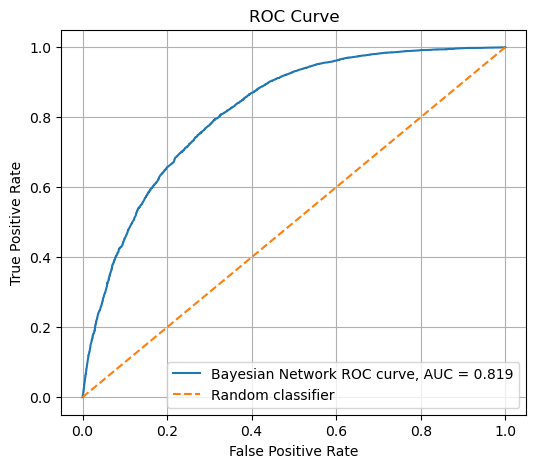

In [ ]:
#compute the accuracy and the auc
acc  = accuracy_score(y_test, y_pred_hc)
auc  = roc_auc_score(y_test, y_prob_hc)

y_true = np.array(df_test['Diabetes_binary'])
fpr, tpr, thresholds = roc_curve(y_true, y_prob_hc)

# Youden's J statistic
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_fpr = fpr[best_index]

print(f'Bayesian Network with HillClimbing algorithm :\n Accuray = {round(acc, 3)} | AUC = {round(auc, 3)} | Specificity = {round(1 - best_fpr, 3)}')

# plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Bayesian Network ROC curve, AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# 4 - Inference 


In [ ]:
inference = VariableElimination(bn_hc)

def diabetes_probability(evidence, label=''):
    """
        Compute the probability that a patient is diabetic or not given some evidence. Print the two probalities 
        and return the probability p1 that the given patient is diabetic.
    Param:
        > evidence : dictionary with the evidence features and their values
        > label    : string representing the characteristics of the given patient that will be printed
    """

    print(label)
    
    res = inference.query(variables=[TARGET], evidence=evidence, show_progress=False)
    p0, p1 = res.values[0], res.values[1]

    print(f'  P(Non-Diabetic) = {round(p0*100, 2)}%')
    print(f'  P(Diabetic)     = {round(p1*100, 2)}%  \n')
    
    return p1

p_hr = diabetes_probability({'Age':9,'BMI':3,'HighBP':1,'HighChol':1,'PhysActivity':0,'GenHlth':4},
             'Profil 1 - 60-64 years old, obesity I, high Blood Pressure, High cholesterol, sedentary')

p_lr = diabetes_probability({'Age':3,'BMI':1,'HighBP':0,'HighChol':0,'PhysActivity':1,'GenHlth':1},
             'Profil 2 - 25-34 years old, normal weight, active, great health')

p_ob = diabetes_probability({'BMI':4},
             'Profil 3 - obesity II+')

p_card = diabetes_probability({'Age':7,'Stroke':1,'HeartDiseaseorAttack':1,'HighBP':1,'BMI':2},
               'Profil 4 - 50-54 years old, stroke, heart disease, overweight')

Profil 1 - 60-64 years old, obesity I, high Blood Pressure, High cholesterol, sedentary
  P(Non-Diabetic) = 10.96%
  P(Diabetic)     = 89.04%  

Profil 2 - 25-34 years old, normal weight, active, great health
  P(Non-Diabetic) = 98.77%
  P(Diabetic)     = 1.23%  

Profil 3 - obesity II+
  P(Non-Diabetic) = 26.51%
  P(Diabetic)     = 73.49%  

Profil 4 - 50-54 years old, stroke, heart disease, overweight
  P(Non-Diabetic) = 29.23%
  P(Diabetic)     = 70.77%  

